<h2>Data Analytics- notebook, empty template</h2>

<h4><b>Dataset name / short description:</b></h4>

Motorcycle Sales Data

<h4><b>Data source (url):</b></h4>

From the Moodle environment.
https://moodle.eoppimispalvelut.fi/pluginfile.php/2838470/mod_resource/content/1/Data_Analytics_Notebook_example.ipynb

<h4><b>Data format:</b></h4>

Describe file structure here.

<h4><b>Data description, features and limitations:</b></h4>

Write needed descriptions here.

<h3><b>Code: importing modules, custom functions and loading the data</b></h3>

In [109]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("motorcycle_sales.csv")
df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1st owner,500000,52000.0
1057,Honda CB twister,16000,2012,Individual,1st owner,33000,51000.0
1058,Bajaj Discover 125,15000,2013,Individual,2nd owner,35000,57000.0
1059,Honda CB Shine,12000,2009,Individual,1st owner,53000,58000.0


<h3><b>Code: Data clean-up procedure</b></h3>

There's already a few problems here.

Specifically, the name column has both the brand and model name in it. It's a big jumble of words and a mess. Also, the owner column is a text datatype. We should convert that to an integer type. 

I don't think we can parse both the model and make from the name column. 

In [110]:
# That's quite a few null values, let's drop the column.
df.isna().sum()

# Dropping the column.
df = df.drop('ex_showroom_price', axis=1)


In [111]:
# Let's replace this with numbers, it's more useful that way (for correlations and such)
df['owner'].value_counts()

# We fill the mapper with all the values we're going to translate
category_mapper = {'1st owner':1,
                   '2nd owner':1,
                   '3rd owner':2,
                   '4th owner':3
}

# And we apply the mapper.
df['owner'] = df['owner'].map(category_mapper)
df.head(5)

,name,selling_price,year,seller_type,owner,km_driven
0,Royal Enfield Classic 350,175000,2019,Individual,1,350
1,Honda Dio,45000,2017,Individual,1,5650
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1,12000
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1,23000
4,Yamaha SZ [2013-2014],20000,2011,Individual,1,21000


In [112]:
# Next up, we'll make a custom function that divides the model and make
# This is a bit of a rough solution, but the main idea is to get insights anyways.


def make_divider(row):
    row = row.split(" ")
    row = row[0]
    return row

# And we'll apply the function.
df['make'] = df['name'].apply(make_divider)
df

,name,selling_price,year,seller_type,owner,km_driven,model
0,Royal Enfield Classic 350,175000,2019,Individual,1,350,Royal
1,Honda Dio,45000,2017,Individual,1,5650,Honda
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1,12000,Royal
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1,23000,Yamaha
4,Yamaha SZ [2013-2014],20000,2011,Individual,1,21000,Yamaha
...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1,500000,Activa
1057,Honda CB twister,16000,2012,Individual,1,33000,Honda
1058,Bajaj Discover 125,15000,2013,Individual,1,35000,Bajaj
1059,Honda CB Shine,12000,2009,Individual,1,53000,Honda


In [113]:
# This custom function will roughly get the make of the motorcycle
def model]_parser(row):
    row = row.split(" ")
    row.pop(0)
    row = " ".join(row)
    return row

# And we'll apply the function.
df['model'] = df['name'].apply(model_parser)
df

,name,selling_price,year,seller_type,owner,km_driven,model,make
0,Royal Enfield Classic 350,175000,2019,Individual,1,350,Royal,Enfield Classic 350
1,Honda Dio,45000,2017,Individual,1,5650,Honda,Dio
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1,12000,Royal,Enfield Classic Gunmetal Grey
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1,23000,Yamaha,Fazer FI V 2.0 [2016-2018]
4,Yamaha SZ [2013-2014],20000,2011,Individual,1,21000,Yamaha,SZ [2013-2014]
...,...,...,...,...,...,...,...,...
1056,Activa 3g,17000,2010,Individual,1,500000,Activa,3g
1057,Honda CB twister,16000,2012,Individual,1,33000,Honda,CB twister
1058,Bajaj Discover 125,15000,2013,Individual,1,35000,Bajaj,Discover 125
1059,Honda CB Shine,12000,2009,Individual,1,53000,Honda,CB Shine


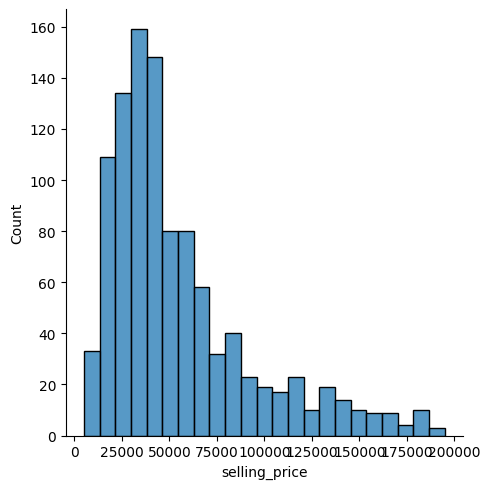

In [114]:
# Let's find out what the distribution looks like!

# There are a couple selling prices that are skewing the data, making the pairplot a bit difficult to see.
# We'll remove those outliers.
df = df[df['selling_price'] < 200000]
sns.displot(df, x='selling_price')

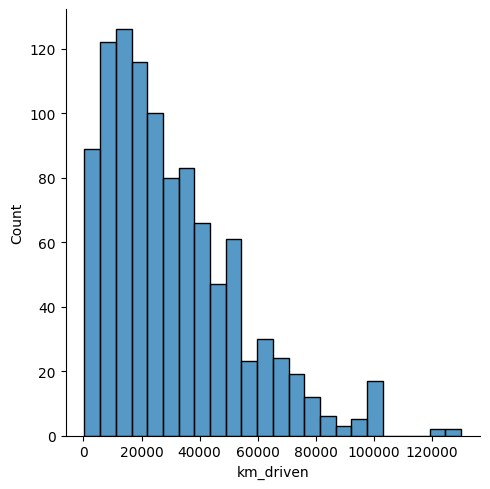

In [115]:
# There's some huge outliers here as well. Let's get rid of those too.
df = df[df['km_driven'] < 180000]
sns.displot(df, x='km_driven')

# Not perfect, but it's better.


In [116]:
# Since there are only a few ownership categories, we should try to use OneHotEncoder on that (so we can try to use that to turn the categories
# nominal variables to see if it will help us in the correlation matrix. 

# Let's also save this as a separate variable in case we would like the categorical variable (for example, plots)

df1 = df

from sklearn.preprocessing import OneHotEncoder
variables = ['seller_type']

encoder = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
one_hot_encoded = encoder.fit_transform(df1[variables]).astype(int)
df1 = pd.concat([df1, one_hot_encoded], axis=1).drop(columns=variables)

In [ ]:
make_counts = df.groupby(df['make']).value_counts()


---

# EDA

---

# Pairplots

Use separate markdown cells if you wish to emphasize an important point or additional information for the reader (see vehicle example)

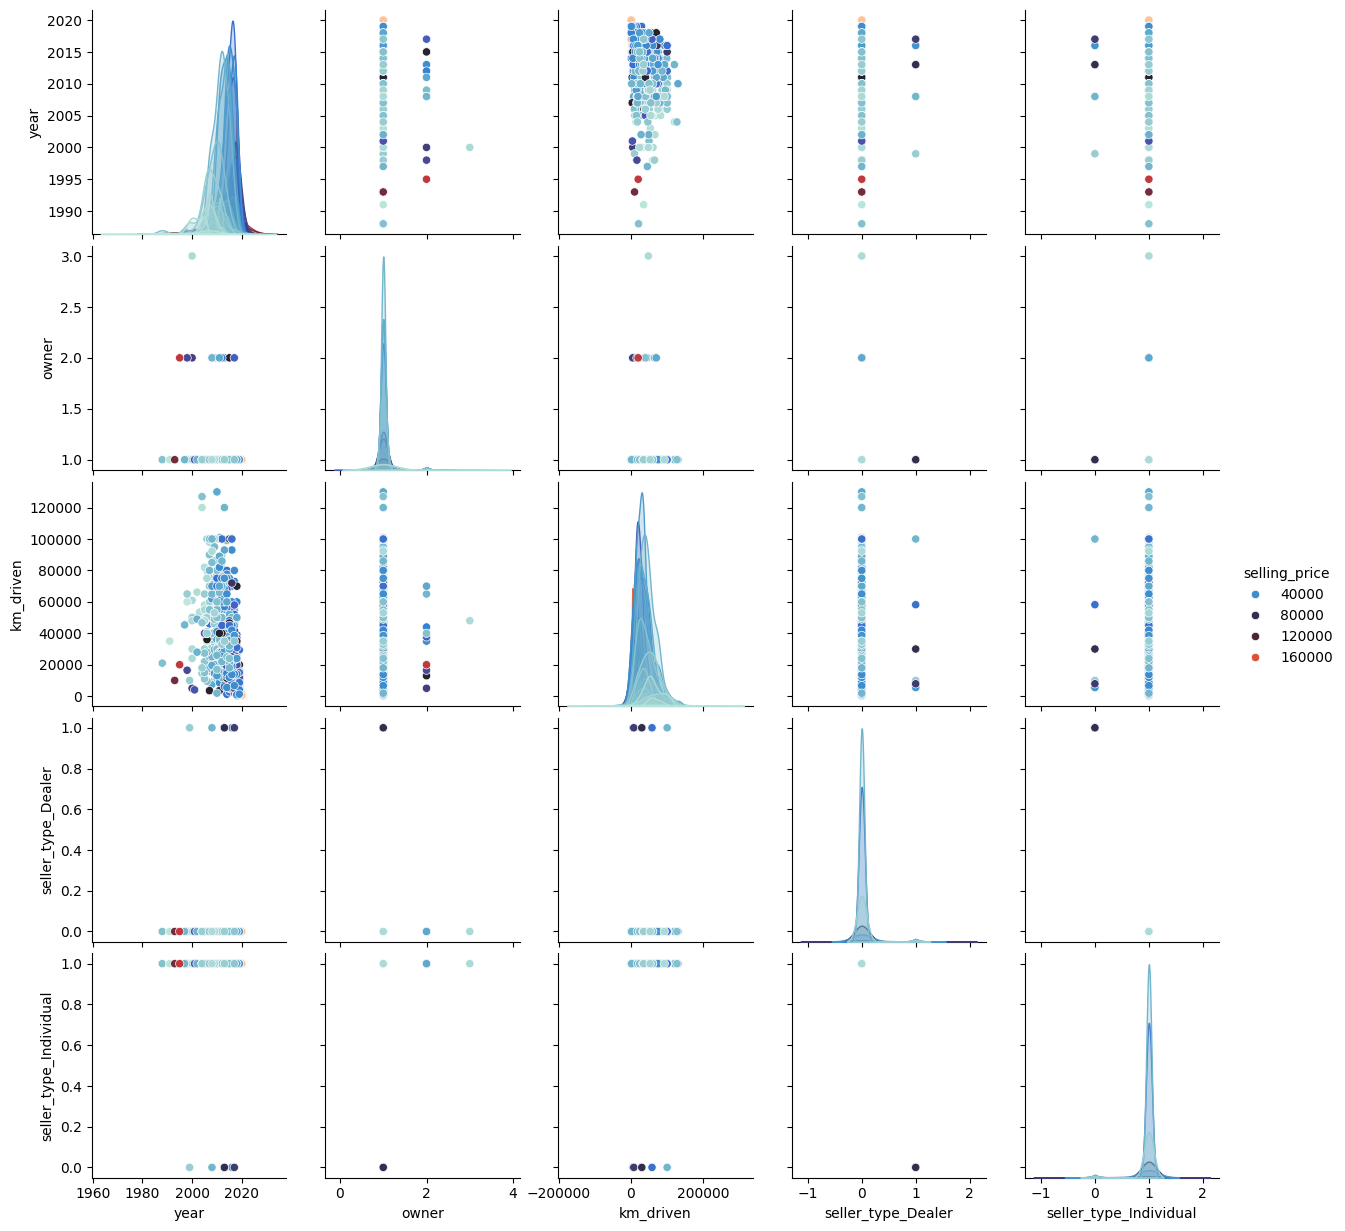

In [117]:
sns.pairplot(df1, hue="selling_price", palette='icefire')

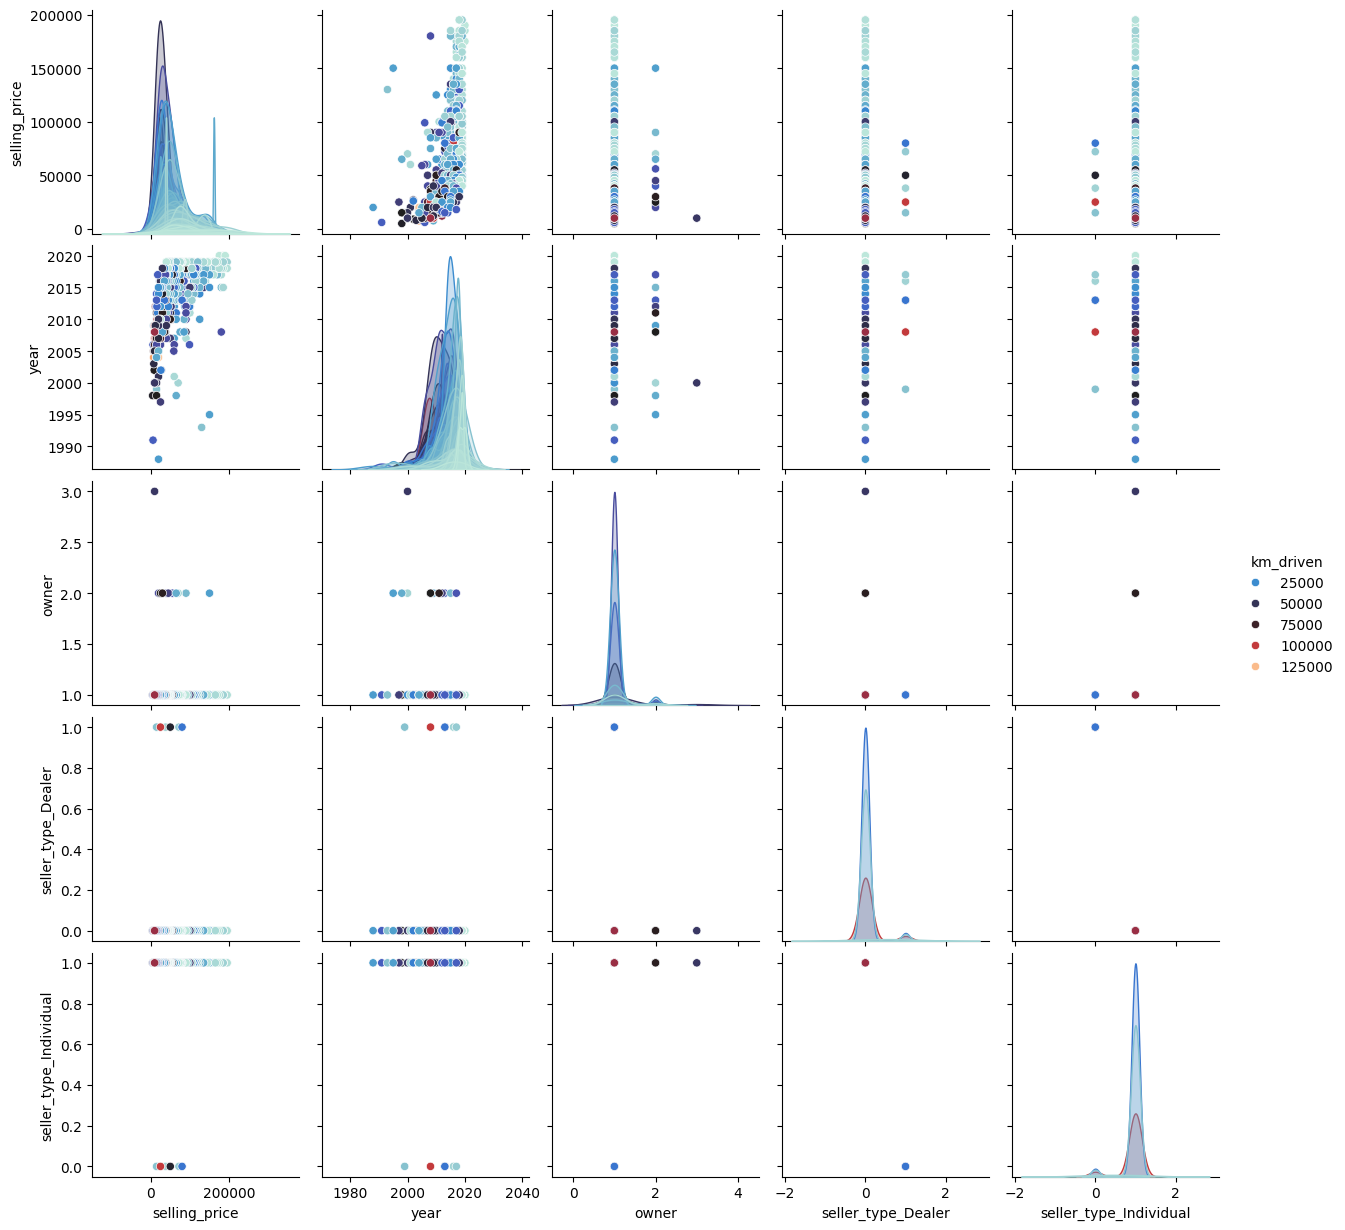

In [118]:
sns.pairplot(df1, hue='km_driven', palette='icefire')

---

# Correlations (Heatmap)

<Axes: >

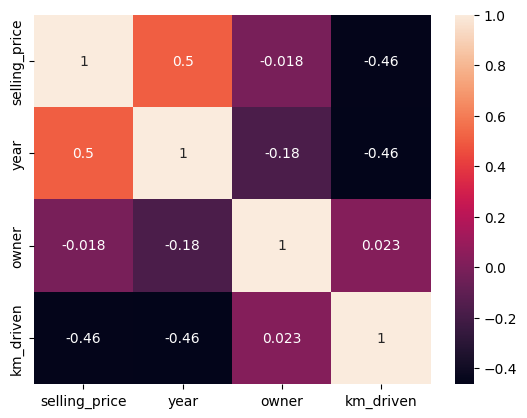

In [120]:
# Heatmap
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation, annot=True)

<div style="border: 3px dashed white; padding: 10px;"> 
<h3>Initial Correlation Observations</h3>

There are three main observations here:

1. The newer the car year, the higher the selling price. This makes sense (with few exceptions like classic cars, but we got rid of quite a few of those outliers.)
2. The less kilometers that arfe driven , the cheaper the price of the car generally is. 
3. <strong style='color:red'>Dealers</strong> also seem to be <strong style='color:red'>selling at less of a price than individual owners.</strong> How could that be? Shouldn't dealers try to make a profit? Don't they buy the cars from individuals and then sell them as well? 

The third observation really doesn't make sense here at face value. My guess right now, is that there are is a distribution skew between dealers and used cars. 





</div>

In [121]:
# Here we can see that there is an ABSOLUTELY MASSIVE distribution skew here. I suspected as much because it doesn't make sense that 
# dealers make less money.
df['owner'].value_counts()

owner
1    1021
2      11
3       1
Name: count, dtype: int64

In [124]:
# And here is the issue. The distribution here for dealers is so small that it renders the column virtually unsusable. 
# Now it's just noise that affects the data. Let's filter it out. 
df['seller_type'].value_counts()

seller_type
Individual    1027
Dealer           6
Name: count, dtype: int64

In [126]:
# Let's filter out the 'Dealership' values.
df = df[df['seller_type'] == "Individual"]

# And since it is sort of redundant, let's also get rid of the column. This is NOW a dataset about Individual motorcycle sales data.
df = df.drop('seller_type', axis=1)

---

# Plots

In [127]:
df

,name,selling_price,year,owner,km_driven,model,make
0,Royal Enfield Classic 350,175000,2019,1,350,Royal,Enfield Classic 350
1,Honda Dio,45000,2017,1,5650,Honda,Dio
2,Royal Enfield Classic Gunmetal Grey,150000,2018,1,12000,Royal,Enfield Classic Gunmetal Grey
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,1,23000,Yamaha,Fazer FI V 2.0 [2016-2018]
4,Yamaha SZ [2013-2014],20000,2011,1,21000,Yamaha,SZ [2013-2014]
...,...,...,...,...,...,...,...
1055,Bajaj ct 100,18000,2017,1,35000,Bajaj,ct 100
1057,Honda CB twister,16000,2012,1,33000,Honda,CB twister
1058,Bajaj Discover 125,15000,2013,1,35000,Bajaj,Discover 125
1059,Honda CB Shine,12000,2009,1,53000,Honda,CB Shine


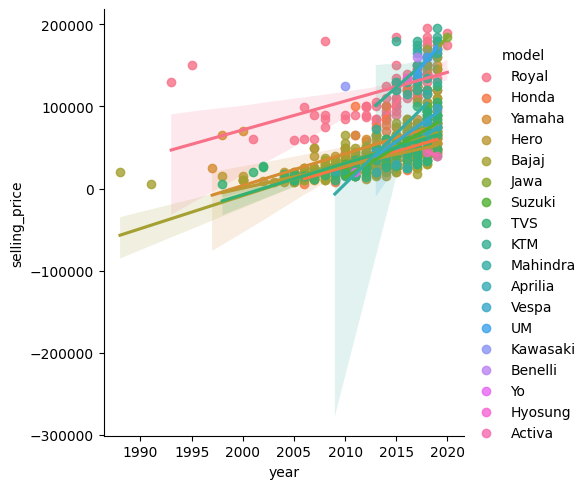

In [130]:
sns.lmplot(df,x='year', y='selling_price', hue='model')

<h3><b>Results and summary:</b></h3>

Write your summary and main results here. 

<h3><b>Ideas for further improvements:</b></h3>

Write your ideas here.